In [1]:
import Symbolics as Sym
using Nemo
using Statistics
using Distributions
using Combinatorics
using Random
using DataFrames
using Plots
using Latexify

import probability: prob, event_occurency, datas, ranks, face_cards, numbers

# Conundrums of Conditional Probability

## Lecture 10

In this lecture we’re going to introduce a very basic concept of
probability that’s associated with what happens when we’re asked
a probabilistic question, but then we’re given more information. It
changes the probability because we put ourselves in a more restricted
arena of possibilities.

In [2]:
Sym.@variables p a b A B G BB BG GG GB n Ω; #use sets for events and prob space omega

In [3]:
P(x) = x

P (generic function with 1 method)

### conditional probability

To introduce conditional probability, we will consider a collection of 27 cards
that have been chosen to illustrate the idea. There are 21 black cards, of which
9 are face cards, and 6 red cards, of which 3 are face cards.

In [4]:
cards = flatten(datas.cards_df, [:ranks])

Row,suits,color,ranks
,Char,String,Any
1,♣,black,2
2,♣,black,3
3,♣,black,4
4,♣,black,5
5,♣,black,6
6,♣,black,7
7,♣,black,8
8,♣,black,9
9,♣,black,10


In [5]:
groupby(filter(c -> c.color == "black", cards), [:color])

Row,suits,color,ranks
,Char,String,Any
1,♣,black,2
2,♣,black,3
3,♣,black,4
4,♣,black,5
5,♣,black,6
6,♣,black,7
7,♣,black,8
8,♣,black,9
9,♣,black,10


In [6]:
fillcombinations(cards, [:ranks], allowduplicates=true)

Row,suits,color,ranks
,Char?,String?,Any
1,♣,black,2
2,♢,red,2
3,♡,black,2
4,♠,red,2
5,♣,black,3
6,♢,red,3
7,♡,black,3
8,♠,red,3
9,♣,black,4


In [7]:
card_colected = shuffle(cards)

Row,suits,color,ranks
,Char,String,Any
1,♠,red,3
2,♠,red,Q
3,♡,black,K
4,♠,red,6
5,♣,black,6
6,♢,red,8
7,♣,black,7
8,♢,red,9
9,♠,red,8


In [8]:
21 - 9

12

In [9]:
black_cards = vcat(first(filter(c -> c.color == "black" && c.ranks in numbers, card_colected), 13), 
first(filter(c -> c.color == "black" && c.ranks in face_cards, card_colected), 9))

Row,suits,color,ranks
,Char,String,Any
1,♣,black,6
2,♣,black,7
3,♡,black,7
4,♡,black,8
5,♡,black,6
6,♣,black,8
7,♣,black,10
8,♡,black,4
9,♣,black,4


In [10]:
red_cards = first(filter(c -> c.color == "red", card_colected), 6)

Row,suits,color,ranks
,Char,String,Any
1,♠,red,3
2,♠,red,Q
3,♠,red,6
4,♢,red,8
5,♢,red,9
6,♠,red,8


In [11]:
cards_selections = vcat(red_cards, black_cards)

Row,suits,color,ranks
,Char,String,Any
1,♠,red,3
2,♠,red,Q
3,♠,red,6
4,♢,red,8
5,♢,red,9
6,♠,red,8
7,♣,black,6
8,♣,black,7
9,♡,black,7


We can answer
questions about the probability of choosing a certain type of card from this
group of cards. What is the probability of choosing a face card? Because we
have 12 face cards, the answer is

In [12]:
count(c -> c in face_cards, cards_selections.ranks)/size(cards_selections)[1]

0.3333333333333333

What is the probability of choosing a red card?

In [13]:
size(red_cards)[1]/size(cards_selections)[1]

0.2222222222222222

Conditional
probability enters the picture when we are told one of the characteristics that
cuts down the population. For example, what is the probability of getting a
red card given that we have chosen a face card?

In [14]:
size(filter(c -> c.color == "red" && c.ranks in face_cards, cards_selections))[1] / count(c -> c in face_cards, cards_selections.ranks)

0.1111111111111111

Let’s look at another question that relates two different conditional
probabilities. What is the probability of getting a face card that is red? This
question involves two probabilities: the probability of choosing a face card
46
and the conditional probability of choosing a red card given that we have
a face card. The answer is the product of two probabilities:

In [15]:
count(c -> c in face_cards, cards_selections.ranks)/size(cards_selections)[1] * 
size(filter(c -> c.color == "red" && c.ranks in face_cards, cards_selections))[1] / size(cards_selections)[1]

0.012345679012345678

We can look at the same situation backward. What is
the probability of getting a red card that is a face card? The analysis is the
same:

In [16]:
size(red_cards)[1],size(cards_selections)[1], size(filter(c -> c.color == "red" && c.ranks in face_cards, cards_selections))[1], size(red_cards)[1]

(6, 27, 1, 6)

In [17]:
6//27 * 3//6 ~ 6/27 * 3/6

1//9 ~ 0.1111111111111111

### Bayes’ theorem.

Bayes’ theorem is a principal tool that is used to deal with conditional
probability. Suppose A represents one characteristic (such as “red card”) and
B represents another characteristic (such as “face card”). Bayes’ theorem
relates two conditional probabilities, the probability of A given B and the
probability of B given A. It can be presented in two ways:

In [18]:
P(B) * P(ifelse(false, A, B)) ~ P(A) * P(ifelse(false, B, A))

B^2 ~ A^2

In [19]:
P(ifelse(false, A, B)) ~ (P(ifelse(false, B, A)) * P(A))//P(B)

B ~ (A^2) / B

Conditional probability can surprise us. Consider the following scenario:
Suppose you meet a man and learn that he has exactly two children.

In [20]:
Ω = [:BB, :BG, :GG, :GB]

4-element Vector{Symbol}:
 :BB
 :BG
 :GG
 :GB

In [21]:
latexify(1//length(filter(c -> c in Ω, [:BB, :BG])))

L"$\frac{1}{2}$"

Therefore, we know that two of
four possibilities are eliminated (two girls [GG] or an older girl and a younger
boy [GB]), leaving the possibility that he has two boys (BB) or an older boy
and a younger girl (BG). Of the remaining two equally likely possibilities,
one is boy-boy. Thus, the probability that both children are boys given that
the older child is a boy is

In [22]:
latexify(1//length(filter(c -> c in Ω, [:BB, :BG, :GB])))

L"$\frac{1}{3}$"

Notice that the answer is
not 1/2. The information that at least one child is a boy affects the probability
differently than the information that the older child is a boy.

Suppose you had
asked the following question of the man instead: “Do you have a son who was born on a Tuesday?” and he answers, “Yes.” Most people’s intuition is that
this birthday information is irrelevant and should yield the same probability
as the previous version of the problem. To do this calculation, we begin by
writing down all the possible day-of-the week and gender combinations, and
we nd that there are 196 in all. We then narrow down the possibilities by
focusing on the pairs for which at least one child is a boy born on a Tuesday.
We nd we have 13 BB possibilities, 7 BG possibilities, 7 GB possibilities,
and of course, no GG possibilities, for a total of 27.

In [23]:
latexify("$(13//27), $(1//3), $(1//2)")

L"$\frac{13}{27}, \frac{1}{3}, \frac{1}{2}$"

Let’s look at another problem: Suppose we have
two urns, each containing 10 balls. In one urn,
we have 7 blue and 3 red balls, and in the other,
we have 3 blue and 7 red balls. We can’t tell
which urn is which. I select an urn at random
and draw a red ball from it; then I put the ball
back in the urn and choose a ball again from the
same urn, and it is red. I choose a third time and
get a red ball and a fourth time and get a red ball. What is the probability
that the urn I chose was the one with 7 red and 3 blue balls?

In [48]:
urn_lenght = 7 + 3
urn_1 = vcat(repeat([:B], 7), repeat([:R], 3))
urn_2 = vcat(repeat([:B], 3), repeat([:R], 7))

10-element Vector{Symbol}:
 :B
 :B
 :B
 :R
 :R
 :R
 :R
 :R
 :R
 :R

In [72]:
rand_sample_1(times= 4) = rand(urn_1, times)
rand_sample_2(times= 4) = rand(urn_2, times)

rand_sample_2 (generic function with 2 methods)

In [73]:
count(==(:R), rand_sample_1())/urn_lenght

0.1

In [74]:
count(==(:R), rand_sample_2())/urn_lenght

0.4

In [75]:
x_read() = count(==(:R), rand([rand_sample_1(), rand_sample_2()], 10_000)[1])/urn_lenght

x_read (generic function with 1 method)

In [76]:
y_blue() = count(==(:B), rand([rand_sample_1(), rand_sample_2()], 10_000)[1])/urn_lenght

y_blue (generic function with 1 method)

In [77]:
speriment_data = map(c -> [x_read(), y_blue()], 1:10_000)

10000-element Vector{Vector{Float64}}:
 [0.1, 0.2]
 [0.2, 0.4]
 [0.0, 0.4]
 [0.2, 0.2]
 [0.1, 0.2]
 [0.2, 0.0]
 [0.0, 0.3]
 [0.3, 0.4]
 [0.4, 0.3]
 [0.2, 0.2]
 ⋮
 [0.1, 0.1]
 [0.1, 0.0]
 [0.3, 0.1]
 [0.1, 0.3]
 [0.3, 0.2]
 [0.2, 0.1]
 [0.1, 0.4]
 [0.1, 0.4]
 [0.2, 0.2]

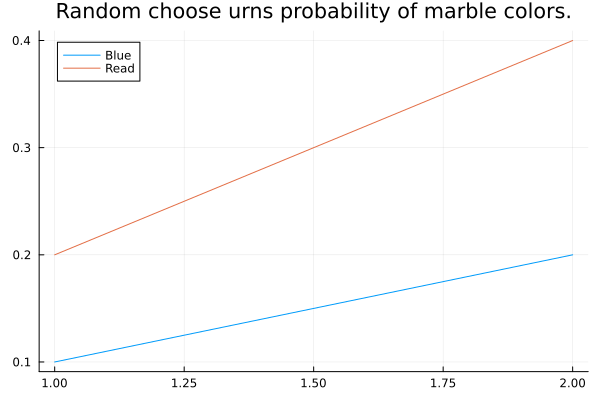

In [78]:
plot(speriment_data[1], label="Blue", title="Random choose urns probability of marble colors.")
plot!(speriment_data[2], label="Read")

**Logically, about half the people (10,000) would choose the blue-heavy urn and half, the red-heavy urn.**

Out of the 10,000 people who chose the red-heavy urn, how many would we
expect to choose red balls four times in a row? Each of the four times one
of the people reaches into the red-heavy urn, he or she has a 70% chance of
getting a red ball. Therefore, we arrive at this equation:

In [79]:
(0.7)^4

0.24009999999999995

However, for the blue-heavy urn,
people have only a 30% chance of getting a red ball each of the four times a
ball is chosen. The equation is:

In [80]:
(0.3)^4

0.0081

We know, then, that 2482 people would draw four red balls.
Therefore, the probability that the person choosing four reds is drawing from
the red-heavy urn is

In [81]:
2401/2482

0.967365028203062

Let’s change the scenario a little and draw a ball out of an urn 50 times
instead of 4 times. Let’s say we nd that 27 times, we choose a red ball, and
23 times, we choose blue. What is the probability that we are choosing from
the red-heavy urn? Surprisingly, our calculations show us that the probability
is again

In [301]:
count(==(:R), rand_sample_1(50))//count(==(:B), rand_sample_2(50)) ~ .97

17//16 ~ 0.97